# Data Mining Final Project — Computer Science Journal Finder

Adile Büşra Kaban,
20220808070

## Project Overview

For this project, I implemented a journal recommendation system tailored to computer science subject areas. There was a given dataset of **7,711 articles from 175 Computer Science journals** (sourced from the Web of Science database), and the two main objectives of this project are:

1. **Generate topic clusters** — group the articles into subject area clusters using unsupervised learning
2. **Build a journal finder** — given a new article's abstract, list the top 5 most relevant journals for submission

The dataset provides per-article information including the abstract text, author-assigned keywords, Web of Science subject classifications, and the journal name.

---

## Step 1: Loading the Dataset

I start by loading `journal_data.csv` using `pandas`. Since I originally developed this notebook in Google Colab but it also needs to run locally (e.g., on other people's computer), I wrote a **path-detection logic**: the code first checks whether the file exists on Google Drive, and if not, it falls back to reading it from the local working directory. This way the notebook can work in both environments without any manual path changes.

I also **manually assigned column names** (`AcademicRecordId`, `AbstractText`, `JournalName`, `Keywords`, `Subjects`) because the CSV file has no header row — without this, pandas would treat the first data row as a header, corrupting the data.

In [ ]:
import pandas as pd
import os


file_name = "journal_data.csv"

drive_path = f"/content/drive/MyDrive/{file_name}"

local_path = file_name

if os.path.exists(drive_path):
    print("Veri Google Drive üzerinden okunuyor...")
    df = pd.read_csv(drive_path, names=['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords', 'Subjects'], header=None)
elif os.path.exists(local_path):
    print("Veri yerel dosya üzerinden okunuyor...")
    df = pd.read_csv(local_path, names=['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords', 'Subjects'], header=None)
else:
    print("HATA: journal_data.csv dosyası bulunamadı! Lütfen dosyayı notebook ile aynı klasöre yükleyin.")

Veri Google Drive üzerinden okunuyor...


## Step 2: Confirming Column Structure

After the smart-loading cell above, I run a second explicit load to **verify that the column names are assigned correctly**. During the development in Google Colab, I used this cell to confirm that `AbstractText` was successfully recognized as a column and that `df.head()` shows sensible data. I print `df.columns` to double-check the structure before moving on to preprocessing.

> **Note for local use:** If you're running this notebook locally, Cell 1 already handled loading correctly. This cell is a Colab-era verification step — it will simply overwrite `df` with the same data using the Drive path, so on a local machine it will fail silently. You can safely skip it if Cell 1 ran without errors.

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/journal_data.csv"


column_names = ['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords', 'Subjects']


df = pd.read_csv(path, names=column_names, header=None)


print(df.columns)
df.head()

Index(['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords',
       'Subjects'],
      dtype='object')


,AcademicRecordId,AbstractText,JournalName,Keywords,Subjects
0,88652,<p>After using evolutionary techniques for sin...,ACM COMPUTING SURVEYS,"algorithms, artificial intelligence, genetic a...","Computer Science, Theory & Methods, Computer S..."
1,88653,<p>Distributed data processing is becoming a r...,ACM COMPUTING SURVEYS,"query optimization, query execution, client-se...","Computer Science, Theory & Methods, Computer S..."
2,88654,<p>Logical models of argument formalize common...,ACM COMPUTING SURVEYS,"defeasible argumentation, argumentative system...","Computer Science, Theory & Methods, Computer S..."
3,88655,<p>In this paper we review studies of the grow...,ACM COMPUTING SURVEYS,"theory, clustering, algorithms, indexing, info...","Computer Science, Theory & Methods, Computer S..."
4,88656,<p>We survey the current techniques to cope wi...,ACM COMPUTING SURVEYS,"edit distance, Levenshtein distance, online st...","Computer Science, Theory & Methods, Computer S..."


## Step 3: Text Preprocessing with NLP

Before I can apply any machine learning algorithm, I needed to convert the raw text into a **clean, normalized format**. Raw article abstracts contain HTML tags, punctuation, numbers, and grammatically inflected words — none of which help a clustering algorithm distinguish topics. I applied three standard NLP preprocessing techniques:

| Technique | The Reason I Use It |
|-----------|-------------|
| **HTML tag removal** | Abstracts are stored with `<p>` tags from the database — I strip these with a regex so they don't pollute the vocabulary |
| **Stopword removal** | Words like *"the"*, *"is"*, and *"and"* appear in every document and carry no topic signal — I remove them using NLTK's English stopword list |
| **Lemmatization** | I reduce inflected words to their base form (e.g., *"running"* → *"run"*, *"algorithms"* → *"algorithm"*) so the model treats them as the same concept |

I defined a `clean_text()` function that applies all three steps, then I apply it to the `AbstractText`, `Keywords`, and `Subjects` columns separately. I then **merge all three into a single `all_text` feature column** because:
- `Keywords` are author-assigned and highlight the core topics directly
- `Subjects` are Web of Science classifications, providing a controlled vocabulary of topic areas
- Together they give the model much richer signals than the abstract alone

This combined feature will be what the TF-IDF vectorizer and K-Means clustering algorithm consume in the next step.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = re.sub(r'<.*?>', '', text)
   
    text = re.sub(r'[^a-zA-Z]', ' ', text)
   
    words = text.lower().split()
   
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned_words)

# Temizlenmiş sütunları oluşturuyoruz
df['clean_abstract'] = df['AbstractText'].apply(clean_text)
df['clean_keywords'] = df['Keywords'].apply(clean_text)
df['clean_subjects'] = df['Subjects'].apply(clean_text)

df['all_text'] = df['clean_abstract'] + " " + df['clean_keywords'] + " " + df['clean_subjects']

df[['JournalName', 'all_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,JournalName,all_text
0,ACM COMPUTING SURVEYS,using evolutionary technique single objective ...
1,ACM COMPUTING SURVEYS,distributed data processing becoming reality b...
2,ACM COMPUTING SURVEYS,logical model argument formalize commonsense r...
3,ACM COMPUTING SURVEYS,paper review study growth internet technology ...
4,ACM COMPUTING SURVEYS,survey current technique cope problem string m...


## Step 4: TF-IDF Vectorization and K-Means Clustering

Now that I have clean text, I needed to convert it into numerical vectors — machine learning algorithms work with numbers, not strings.

### Why I Used TF-IDF?

I use **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorization. TF-IDF scores each word by how often it appears in a document *relative to how common it is across all documents*. This means:
- A word like *"algorithm"* that appears in one article frequently but rarely elsewhere gets a **high score** → meaningful topic signal
- A word like *"paper"* that appears in nearly every abstract gets a **low score** → discarded as uninformative

I limit the vocabulary to the top **5,000 features** to keep the computation manageable without losing important terms.

### Why K-Means with k=10?

I apply **K-Means clustering** as required by the homework. K-Means partitions all 7,711 articles into `k` groups by iteratively assigning each article to the nearest cluster centroid and recomputing centroids. I use `k=10` (as specified in the project) to create 10 distinct topic groups covering the breadth of computer science subject areas. Setting `n_init=10` means the algorithm runs 10 independent times with different random seeds and keeps the best result — this reduces the risk of converging to a poor local optimum.

### Visualizing with PCA

High-dimensional TF-IDF vectors (5,000 dimensions) can't be directly plotted. I use **PCA (Principal Component Analysis)** to project them down to 2 dimensions, preserving as much variance as possible. The scatter plot then lets me visually inspect whether the 10 clusters are well-separated in topic space. Each dot is an article, colored by its cluster assignment.

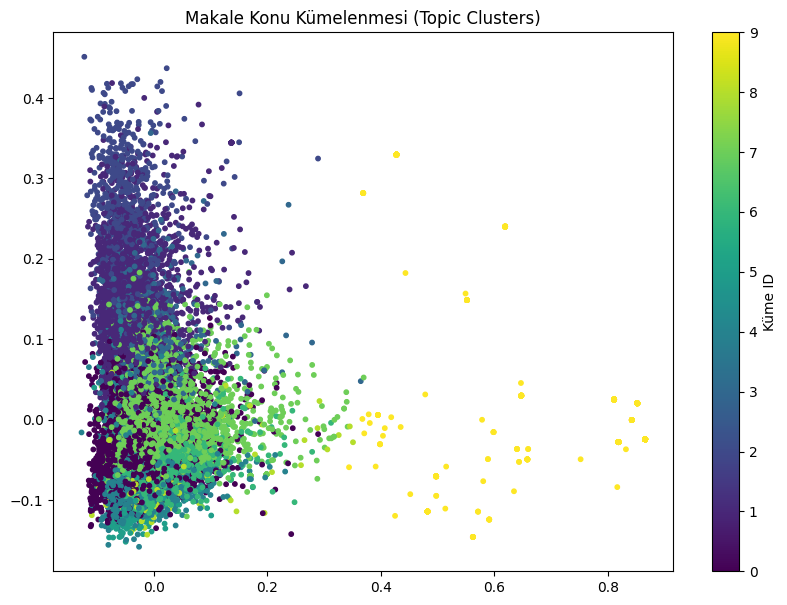

             JournalName  cluster
0  ACM COMPUTING SURVEYS        4
1  ACM COMPUTING SURVEYS        7
2  ACM COMPUTING SURVEYS        6
3  ACM COMPUTING SURVEYS        7
4  ACM COMPUTING SURVEYS        4
5  ACM COMPUTING SURVEYS        4
6  ACM COMPUTING SURVEYS        0
7  ACM COMPUTING SURVEYS        6
8  ACM COMPUTING SURVEYS        0
9  ACM COMPUTING SURVEYS        0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(df['all_text'])

num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], c=df['cluster'], cmap='viridis', s=10)
plt.title('Article Topic Clustering (Topic Clusters)')
plt.colorbar(label='Cluster ID')
plt.show()


print(df[['JournalName', 'cluster']].head(10))

## Step 5: Journal Recommendation System

This is the core deliverable of the project. I build a **content-based recommendation engine** that, given a new article's abstract, returns the 5 most relevant journals to submit to.

### How I Build Journal Profiles

I can't compare a new abstract directly against 7,711 individual articles — that would be slow and noisy. Instead, I computed a **profile vector** for each of the 175 journals by averaging the TF-IDF vectors of all articles published in that journal. This centroid vector represents the journal's overall topic focus. For example, a journal that publishes mostly machine learning papers will have high weights on words like *"neural"*, *"learning"*, and *"classification"* in its profile.

### Why Cosine Similarity?

When a user inputs a new abstract, I:
1. Apply the same `clean_text()` preprocessing pipeline to it
2. Transform it into a TF-IDF vector using the **already-fitted** vectorizer (same vocabulary — critical for compatibility)
3. Compute **cosine similarity** between the input vector and each of the 175 journal profiles

I choose cosine similarity over Euclidean distance because it measures the **angle** between two vectors rather than their absolute distance. This makes it robust to document length differences — a short abstract and a long abstract that cover the same topic will still score high similarity, whereas Euclidean distance would penalize the length mismatch.

A score of **1.0** means the topics are identical; **0.0** means they share nothing in common.

### Top 5 Output

I sort all 175 journals by similarity score in descending order and return the top 5 as the final recommendation. To test the system, I use a sample abstract about deep learning and image processing — intuitively, this should match journals focused on neural networks, computer vision, or applied AI.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Her dergi için ortalama bir vektör (profil) hesaplayalım
# Bu işlem, o dergide yayınlanan tüm makalelerin 'merkezini' bulur
journal_profiles = {}
unique_journals = df['JournalName'].unique()

for journal in unique_journals:
    # O dergiye ait makalelerin satır indekslerini bul
    indices = df[df['JournalName'] == journal].index
    # O indekslerdeki vektörlerin ortalamasını al
    journal_profiles[journal] = np.asarray(X[indices].mean(axis=0))

# 2. Öneri Fonksiyonu
def find_top_5_journals(user_abstract):
    # Kullanıcının metnini temizle ve vektöre dönüştür
    cleaned_input = clean_text(user_abstract)
    input_vector = tfidf.transform([cleaned_input]).toarray()

    similarities = {}
    for journal, profile_vector in journal_profiles.items():
        # Kosinüs benzerliği hesapla
        sim = cosine_similarity(input_vector, profile_vector)[0][0]
        similarities[journal] = sim

    # Benzerlik puanına göre sırala ve ilk 5'i al
    sorted_journals = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    return sorted_journals[:5]

# --- TEST ETME ---
test_abstract = "Deep learning and neural networks are revolutionizing image processing tasks."
results = find_top_5_journals(test_abstract)

print("--- Önerilen İlk 5 Dergi ---")
for i, (journal, score) in enumerate(results, 1):
    print(f"{i}. {journal} (Benzerlik Puanı: {score:.4f})")

--- Önerilen İlk 5 Dergi ---
1. NEURAL PROCESSING LETTERS (Benzerlik Puanı: 0.3650)
2. NEUROCOMPUTING (Benzerlik Puanı: 0.3628)
3. NEURAL NETWORKS (Benzerlik Puanı: 0.2923)
4. NEURAL NETWORK WORLD (Benzerlik Puanı: 0.2556)
5. IEEE TRANSACTIONS ON NEURAL NETWORKS AND LEARNING SYSTEMS (Benzerlik Puanı: 0.2427)


## Conclusion

In this project, I built an end-to-end journal recommendation system for computer science articles. The full pipeline I implemented is:

| Step | What I Did | Why |
|------|-----------|-----|
| 1. Data Loading | Read 7,711 articles from CSV with dual path support | Makes the notebook portable across Colab and local environments |
| 2. Verification | Confirmed column structure and previewed data | Catches data loading issues early |
| 3. NLP Preprocessing | Cleaned abstracts, keywords, and subjects | Raw text must be normalized before ML algorithms can use it |
| 4. TF-IDF + K-Means | Vectorized text and clustered into 10 topic groups | Fulfills the topic clustering requirement; creates the feature matrix for recommendations |
| 5. Cosine Similarity | Built journal profiles and scored input abstracts against them | Enables content-based journal recommendation |

### How to Use the Recommendation System

To recommend journals for your own article, replace the `test_abstract` string in Step 5 with your article's abstract and re-run the cell:

```python
test_abstract = "Paste your article abstract here..."
results = find_top_5_journals(test_abstract)
```

The system will output the top 5 most relevant Computer Science journals along with their similarity scores.